# EDA

Investigate the more exotic issues.

Challenges/Ideas:
- [x] "Low variance" filter for nominal variables
    - Entropy (possible threshold: 0.01 and below considered "low variance")
    - Gini (possible threshold: 0.001 and below considered "low variance")
    - Percentage of column occupied by mode
    - Throw these values into data dictionary to eyeball
- [ ] "Regular customers"
- [ ] Hodges-Lehmann confidence intervals

In [1]:
from pprint import pp

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

In [ ]:
# # If importing bespoke modules.
# import os
# import sys
# from importlib import reload

# sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "scripts"))

In [2]:
%%time
df = pl.read_parquet("../data/diabetic_data.parquet")

CPU times: total: 156 ms
Wall time: 196 ms


---

## Explore low variance filter

... except we cannot calculate variance for nominal variables. 🫤

There are some options:
- Percentage of column occupied by the most frequent value
- Shannon entropy
- Gini impurity

Perhaps we go with Gini impurity for now, since the calculation is slightly simpler, and values are bounded between 0 (homogeneous/pure) and 1 (maximum impurity; 0.5 for 2 classes). Can also calculate percentage ocuupied by the most frequent value anyway to cross-reference.

In [3]:
def calc_gini_impurity(s: pl.Series) -> float:
    p = pl.col("proportion")
    vc = s.value_counts(normalize=True)
    vc = vc.with_columns(p.pow(2).alias("prop2"))
    return 1 - vc["prop2"].sum()


def drop_low_gini(df: pl.DataFrame, threshold: float=0.005, verbose: bool=True) -> pl.DataFrame:
    """
    Might have to try out different thresholds. Start off conservative at
    0.005, which for this dataset, would drop variables where the dominant
    value comprises 99.9% or more of the values.

    Could be more aggressive, possibly up to 0.09 (96.9%), which will
    conveniently drop `weight`, but retain `glimepiride` (0.097, 94.9%).
    """
    to_drop = {}
    for s in df:
        gini = calc_gini_impurity(s)
        if gini < threshold:
            vc = s.value_counts().sort(s.name)
            dct = dict(zip(vc[s.name], vc["count"]))
            to_drop[s.name] = {"Gini": gini, "ModePct": vc["count"].max() / df.height, "Values": dct}
    if verbose:
        n = len(to_drop)
        w1 = len(str(n))
        w2 = max(len(k) for k in to_drop)
        print(f"Dropping the following {n} variables with Gini below: {threshold}")
        for i, (k, v) in enumerate(to_drop.items(), start=1):
            print(f"  {i:0{w1}d}: {k:{w2}}, Gini = {v['Gini']:.6f}, ModePct = {v['ModePct']:.6f}, Values = {v['Values']}")
    df2 = df.drop(to_drop)
    return df2


def drop_manual(df: pl.DataFrame) -> pl.DataFrame:
    df = df.filter(pl.col("gender").ne("Unknown/Invalid"))  # 3 rows.
    df = df.drop("payer_code")  # Probably irrelevant.
    df = drop_low_gini(df, threshold=0.09, verbose=True)
    return df

df2 = drop_manual(df)

Dropping the following 17 variables with Gini below: 0.09
  01: weight                  , Gini = 0.061554, ModePct = 0.968584, Values = {'?': 98566, '[0-25)': 48, '[25-50)': 97, '[50-75)': 897, '[75-100)': 1336, '[100-125)': 625, '[125-150)': 145, '[150-175)': 35, '[175-200)': 11, '>200': 3}
  02: repaglinide             , Gini = 0.029832, ModePct = 0.984877, Values = {'No': 100224, 'Down': 45, 'Steady': 1384, 'Up': 110}
  03: nateglinide             , Gini = 0.013726, ModePct = 0.993092, Values = {'No': 101060, 'Down': 11, 'Steady': 668, 'Up': 24}
  04: chlorpropamide          , Gini = 0.001689, ModePct = 0.999155, Values = {'No': 101677, 'Down': 1, 'Steady': 79, 'Up': 6}
  05: acetohexamide           , Gini = 0.000020, ModePct = 0.999990, Values = {'No': 101762, 'Steady': 1}
  06: tolbutamide             , Gini = 0.000452, ModePct = 0.999774, Values = {'No': 101740, 'Steady': 23}
  07: acarbose                , Gini = 0.006036, ModePct = 0.996973, Values = {'No': 101455, 'Down': 3, '

### That's about 1/3 of the columns dropped with a threshold of 0.09.

Was just looking for an excuse to drop `weight` since it has too many (96.7%) missing values. The rest had 98.5% or more of the column dominated by the mode.

In [4]:
pp(df2.schema, width=200)

Schema([('encounter_id', String),
        ('patient_nbr', String),
        ('race', String),
        ('gender', String),
        ('age', Enum(categories=['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'])),
        ('admission_type_id', String),
        ('discharge_disposition_id', String),
        ('admission_source_id', String),
        ('time_in_hospital', Int64),
        ('medical_specialty', String),
        ('num_lab_procedures', Int64),
        ('num_procedures', Int64),
        ('num_medications', Int64),
        ('number_outpatient', Int64),
        ('number_emergency', Int64),
        ('number_inpatient', Int64),
        ('diag_1', String),
        ('diag_2', String),
        ('diag_3', String),
        ('number_diagnoses', Int64),
        ('max_glu_serum', Enum(categories=['None', 'Norm', '>200', '>300'])),
        ('A1Cresult', Enum(categories=['None', 'Norm', '>7', '>8'])),
        ('metformin', Enum(categories=['

---

## Excursion: "Regular customers"

It has come to our attention that `patient_nbr` has duplicate values. Certain factors, such as demographics, are expected to be repeated. These will violate any independence assumptions. At some point we will need some form of aggregation, perhaps keeping only 1 record per patient, perhaps the earliest (but we lack temporal data to make that determination). This might affect procedures during EDA and beyond.

In [5]:
def calc_n_admissions(df: pl.DataFrame) -> pl.DataFrame:
    """
    Count number of encounters for each `patient_nbr`.
    Run separately if splitting.
    """
    vc = df["patient_nbr"].value_counts().rename({"count": "n_admissions"})
    df = df.drop("n_admissions", strict=False)
    df = df.join(vc, on="patient_nbr", how="left")
    lcols = ["encounter_id", "patient_nbr", "n_admissions"]
    df = df.select(*lcols, pl.exclude(lcols))
    return df


def nadm_xtab(df: pl.DataFrame, thr: int=20, row: str="patient_nbr", col: str="readmitted") -> pl.DataFrame:
    res = (
        df
        .pipe(calc_n_admissions)
        .filter(pl.col("n_admissions").gt(thr))
        .group_by(row, col).len()
        .sort(row, col)
        .pivot(index=row, on=col)
        .sort(pl.sum_horizontal(pl.exclude(row)), descending=True)
    )
    return res

In [6]:
nadm_xtab(df2, thr=20)

patient_nbr,NO,>30,<30
str,u32,u32,u32
"""88785891""",null,17,23
"""43140906""",1,5,22
"""1660293""",1,11,11
"""23199021""",null,16,7
"""88227540""",null,11,12
"""23643405""",1,9,12
"""84428613""",null,10,12
"""92709351""",1,8,12


### Looks like "NO" for `readmitted` only happens once?

Surprise! There are (44) patients which were "not readmitted" twice. Not too sure what this means though. This is really unexpected.

In [7]:
nadm_xtab(df2, thr=0)["NO"].max()

2

In [8]:
nadm_xtab(df2, thr=0).filter(pl.col("NO").gt(1))

patient_nbr,NO,>30,<30
str,u32,u32,u32
"""85295430""",2,5,2
"""102925989""",2,2,1
"""108178776""",2,2,1
"""92029617""",2,2,1
"""92919915""",2,2,1
…,…,…,…
"""60403851""",2,null,null
"""60415740""",2,null,null
"""60653520""",2,null,null


### Nothing obvious stands out at the moment

In [9]:
df2.pipe(calc_n_admissions).filter(pl.col("n_admissions").gt(1) & pl.col("readmitted").eq("NO")).filter(pl.col("patient_nbr").is_duplicated()).sort("patient_nbr")

encounter_id,patient_nbr,n_admissions,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,change,diabetesMed,readmitted
str,str,u32,str,str,enum,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,str,str,str,i64,enum,enum,enum,enum,enum,enum,enum,enum,enum,str,str,enum
"""127648902""","""100908189""",3,"""Caucasian""","""Male""","""[60-70)""","""Elective""","""Discharged/transferred to anot…","""Physician Referral""",4,"""Psychology""",34,0,18,0,0,1,"""mental disorders""","""injury and poisoning""","""injury and poisoning""",9,"""None""","""None""","""No""","""No""","""No""","""No""","""No""","""No""","""Up""","""Ch""","""Yes""","""NO"""
"""127930326""","""100908189""",3,"""Caucasian""","""Male""","""[60-70)""","""Elective""","""Discharged/transferred to SNF""","""Physician Referral""",3,"""InternalMedicine""",1,1,16,0,0,2,"""injury and poisoning""","""diseases of the musculoskeleta…","""mental disorders""",7,"""None""","""None""","""No""","""No""","""No""","""No""","""No""","""No""","""Up""","""Ch""","""Yes""","""NO"""
"""158302332""","""101866896""",2,"""Caucasian""","""Male""","""[40-50)""","""Emergency""","""Discharged/transferred within …","""Physician Referral""",13,"""?""",54,1,13,0,0,0,"""Diabetes mellitus""","""Other metabolic and immunity d…","""Other metabolic and immunity d…",8,"""None""","""None""","""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""Yes""","""NO"""
"""159470610""","""101866896""",2,"""Caucasian""","""Male""","""[40-50)""","""Urgent""","""Discharged/transferred to ICF""","""Physician Referral""",8,"""Family/GeneralPractice""",2,0,7,0,0,1,"""Diabetes mellitus""","""Other metabolic and immunity d…","""diseases of the respiratory sy…",6,"""None""","""None""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""NO"""
"""155387046""","""102440403""",2,"""AfricanAmerican""","""Female""","""[80-90)""","""Emergency""","""Discharged/transferred within …","""Clinic Referral""",9,"""?""",63,0,14,0,0,0,"""diseases of the circulatory sy…","""Other metabolic and immunity d…","""Diabetes mellitus""",9,"""None""","""None""","""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""Yes""","""NO"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""163300704""","""92029617""",5,"""Caucasian""","""Male""","""[80-90)""","""Urgent""","""Discharged/transferred to ICF""","""Physician Referral""",14,"""Family/GeneralPractice""",65,1,30,0,0,3,"""Other metabolic and immunity d…","""diseases of the respiratory sy…","""diseases of the genitourinary …",9,"""None""","""Norm""","""No""","""Steady""","""No""","""No""","""No""","""Steady""","""No""","""Ch""","""Yes""","""NO"""
"""334326602""","""92919915""",5,"""AfricanAmerican""","""Female""","""[50-60)""","""Elective""","""Discharged to home""","""Transfer from a hospital""",14,"""Psychology""",72,0,22,0,2,2,"""mental disorders""","""Diabetes mellitus""","""diseases of the genitourinary …",9,"""None""","""None""","""No""","""No""","""No""","""No""","""No""","""No""","""Down""","""Ch""","""Yes""","""NO"""
"""429082718""","""92919915""",5,"""AfricanAmerican""","""Female""","""[50-60)""","""Urgent""","""Discharged/transferred to anot…","""Transfer from a hospital""",5,"""Family/GeneralPractice""",63,5,17,0,2,1,"""diseases of the circulatory sy…","""diseases of the genitourinary …","""Diabetes mellitus""",9,"""None""","""None""","""No""","""No""","""No""","""No""","""No""","""No""","""Up""","""Ch""","""Yes""","""NO"""


### KIV what 2 "not readmitted" might mean

### Meanwhile, there might be an interesting difference in distributions of `n_admissions` between the target categories

Possible association between admissions and readmissions (makes sense?)

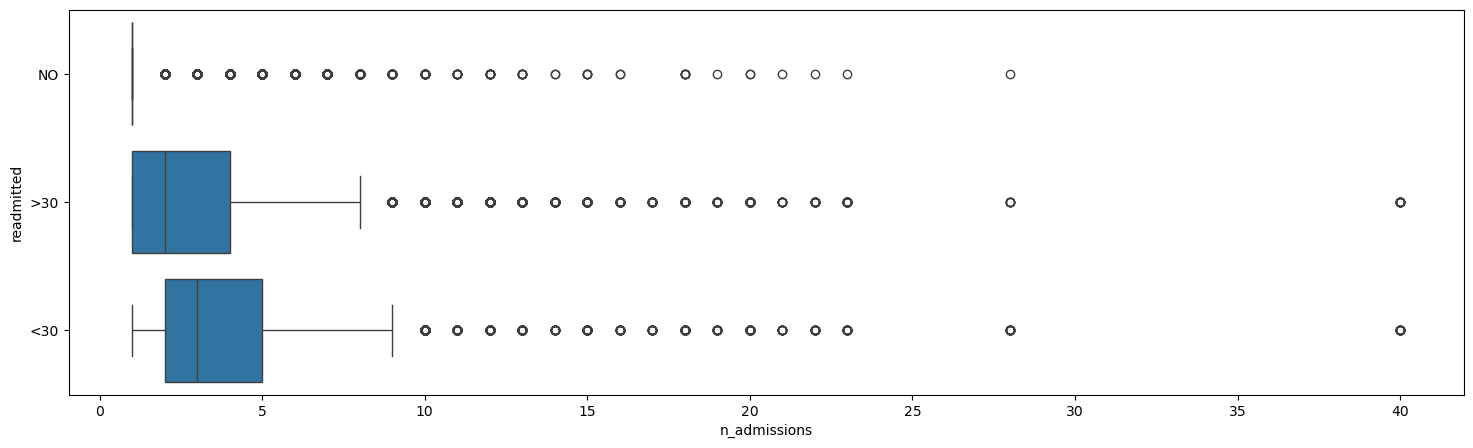

In [10]:
fig, ax = plt.subplots(figsize=(18, 5))
sns.boxplot(df2.pipe(calc_n_admissions).to_pandas(), x="n_admissions", y="readmitted", ax=ax);

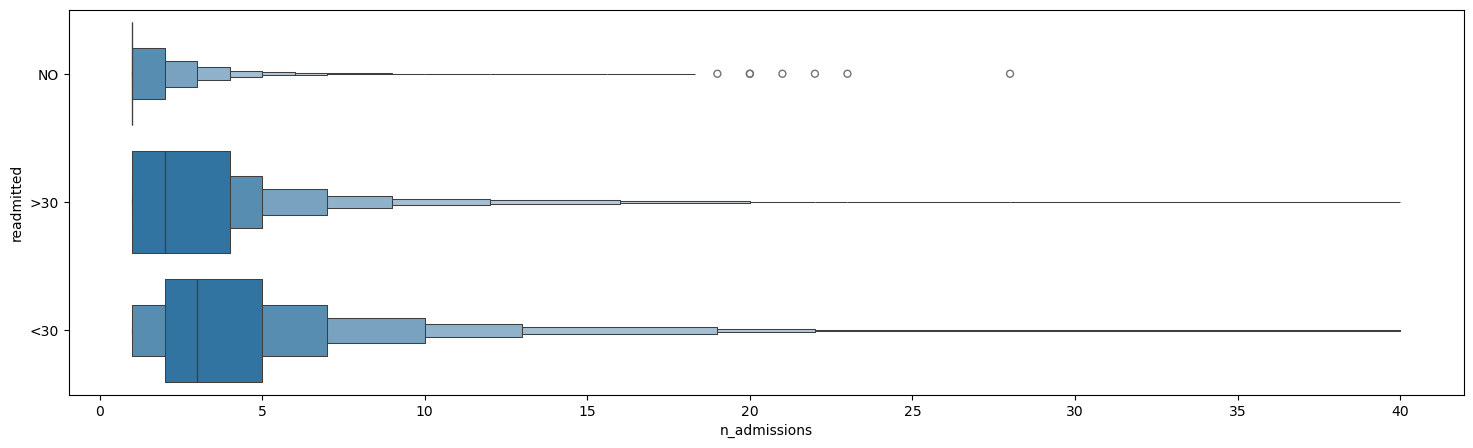

In [11]:
fig, ax = plt.subplots(figsize=(18, 5))
sns.boxenplot(df2.pipe(calc_n_admissions).to_pandas(), x="n_admissions", y="readmitted", ax=ax);

### Scatterplots are tricky in this case

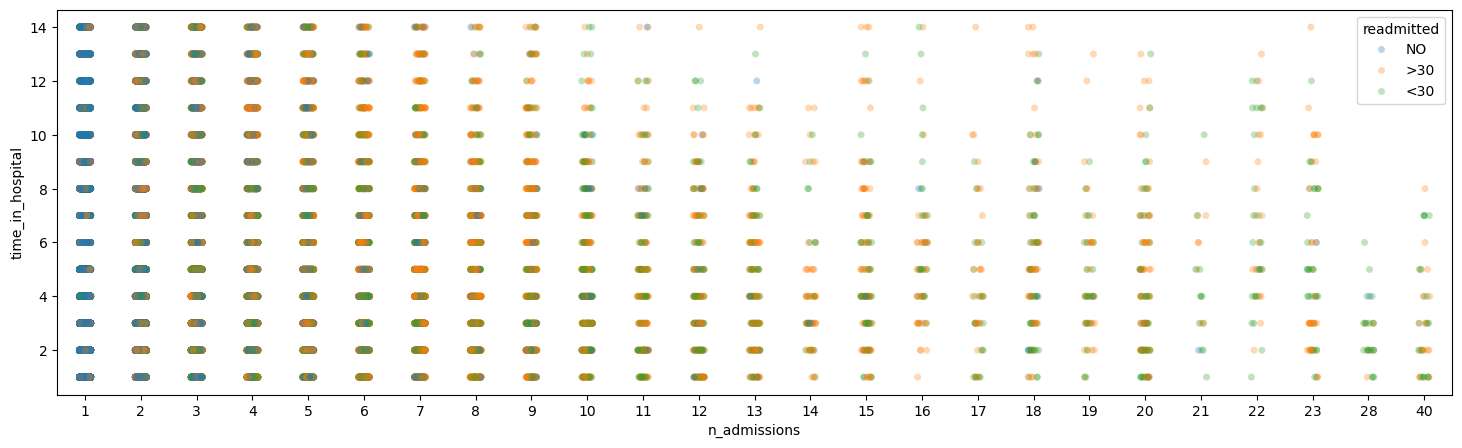

In [12]:
fig, ax = plt.subplots(figsize=(18, 5))
sns.stripplot(df2.pipe(calc_n_admissions).to_pandas(), x="n_admissions", y="time_in_hospital", hue="readmitted", alpha=0.3, ax=ax);

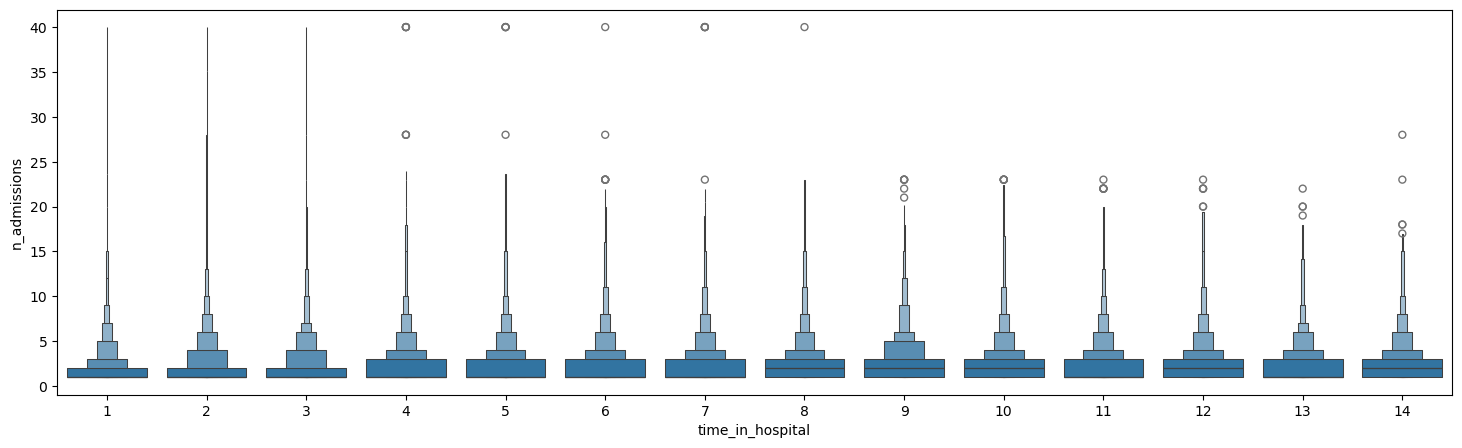

In [13]:
fig, ax = plt.subplots(figsize=(18, 5))
sns.boxenplot(df2.pipe(calc_n_admissions).to_pandas(), x="time_in_hospital", y="n_admissions", ax=ax);

---

## Excursion: `age`

The original authors divided the age variable into 3 categories ([0, 30), [30, 60), [60, 100)) after observing _something_. We've not done logistic regression at this point, but perhaps we can do some simple proportions.

NOTE: Duplicate patients have not been handled at this point, so the numbers would not be the most accurate.

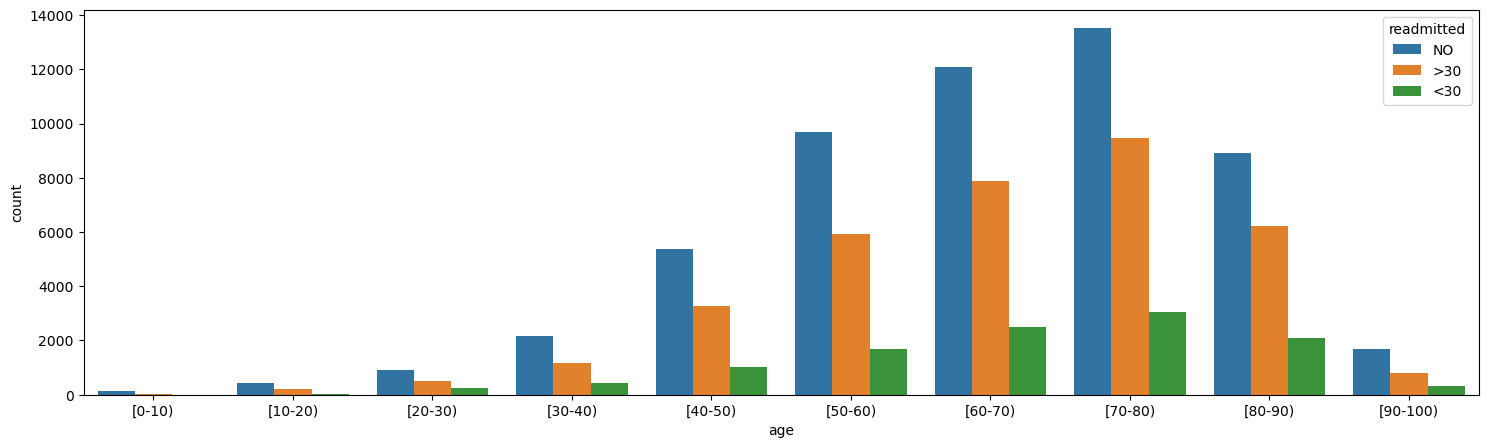

In [14]:
fig, ax = plt.subplots(figsize=(18, 5))
sns.countplot(df2.to_pandas(), x="age", hue="readmitted", ax=ax);

In [15]:
def calc_prob_readm(df: pl.DataFrame) -> pl.DataFrame:
    tot = pl.sum_horizontal(pl.exclude("age"))
    df = df.group_by("age", "readmitted").len().sort("age", "readmitted").pivot(index="age", on="readmitted")
    df = df.with_columns(((tot - pl.col("NO")) / tot).alias("prop_readmit"))
    df = df.with_columns((pl.col("<30") / tot).alias("prop_early_readmit"))
    df = df.unpivot(on=["prop_readmit", "prop_early_readmit"], index="age")
    return df

calc_prob_readm(df2)

age,variable,value
enum,str,f64
"""[0-10)""","""prop_readmit""",0.180124
"""[10-20)""","""prop_readmit""",0.382055
"""[20-30)""","""prop_readmit""",0.450211
"""[30-40)""","""prop_readmit""",0.426755
"""[40-50)""","""prop_readmit""",0.444502
…,…,…
"""[50-60)""","""prop_early_readmit""",0.09666
"""[60-70)""","""prop_early_readmit""",0.111287
"""[70-80)""","""prop_early_readmit""",0.117737


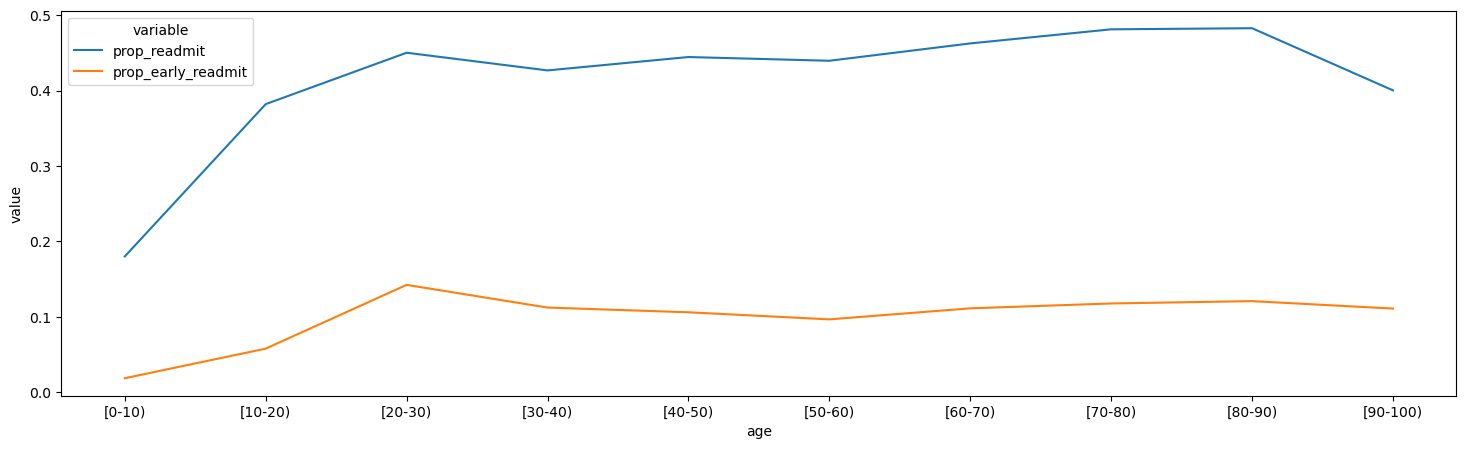

In [16]:
fig, ax = plt.subplots(figsize=(18, 5))
sns.lineplot(calc_prob_readm(df2).to_pandas(), x="age", y="value", hue="variable", ax=ax);

### Not easily seeing what they saw...

---

## Diagnoses (ICD-9 recoded): `diag_1`, `diag_2`, `diag_3`

In [17]:
with pl.Config(fmt_str_lengths=200, tbl_rows=-1) as cfg:
    display(df2["diag_1"].value_counts(sort=True))

diag_1,count
str,u32
"""diseases of the circulatory system""",30335
"""diseases of the respiratory system""",10407
"""diseases of the digestive system""",9208
"""Diabetes mellitus""",8757
"""symptoms, signs, and ill-defined conditions""",7636
"""injury and poisoning""",6972
"""diseases of the genitourinary system""",5078
"""diseases of the musculoskeletal system and connective tissue""",4957
"""neoplasms""",3433


### Regrets
- Should have given them shorter labels

### Observations
- Diseases of the circulatory system dominates
- Followed by diabetes mellitus or diseases of the respiratory system
- The original authors did not observe their hypothesis for patients without a primary diagnosis of diabetes mellitus

### Decisions
- Should we reduce the number of categories?
- Should we eliminate some categories?
- Should we keep primary and secondary diagnoses separate?
- Should we eliminate certain diagnoses?

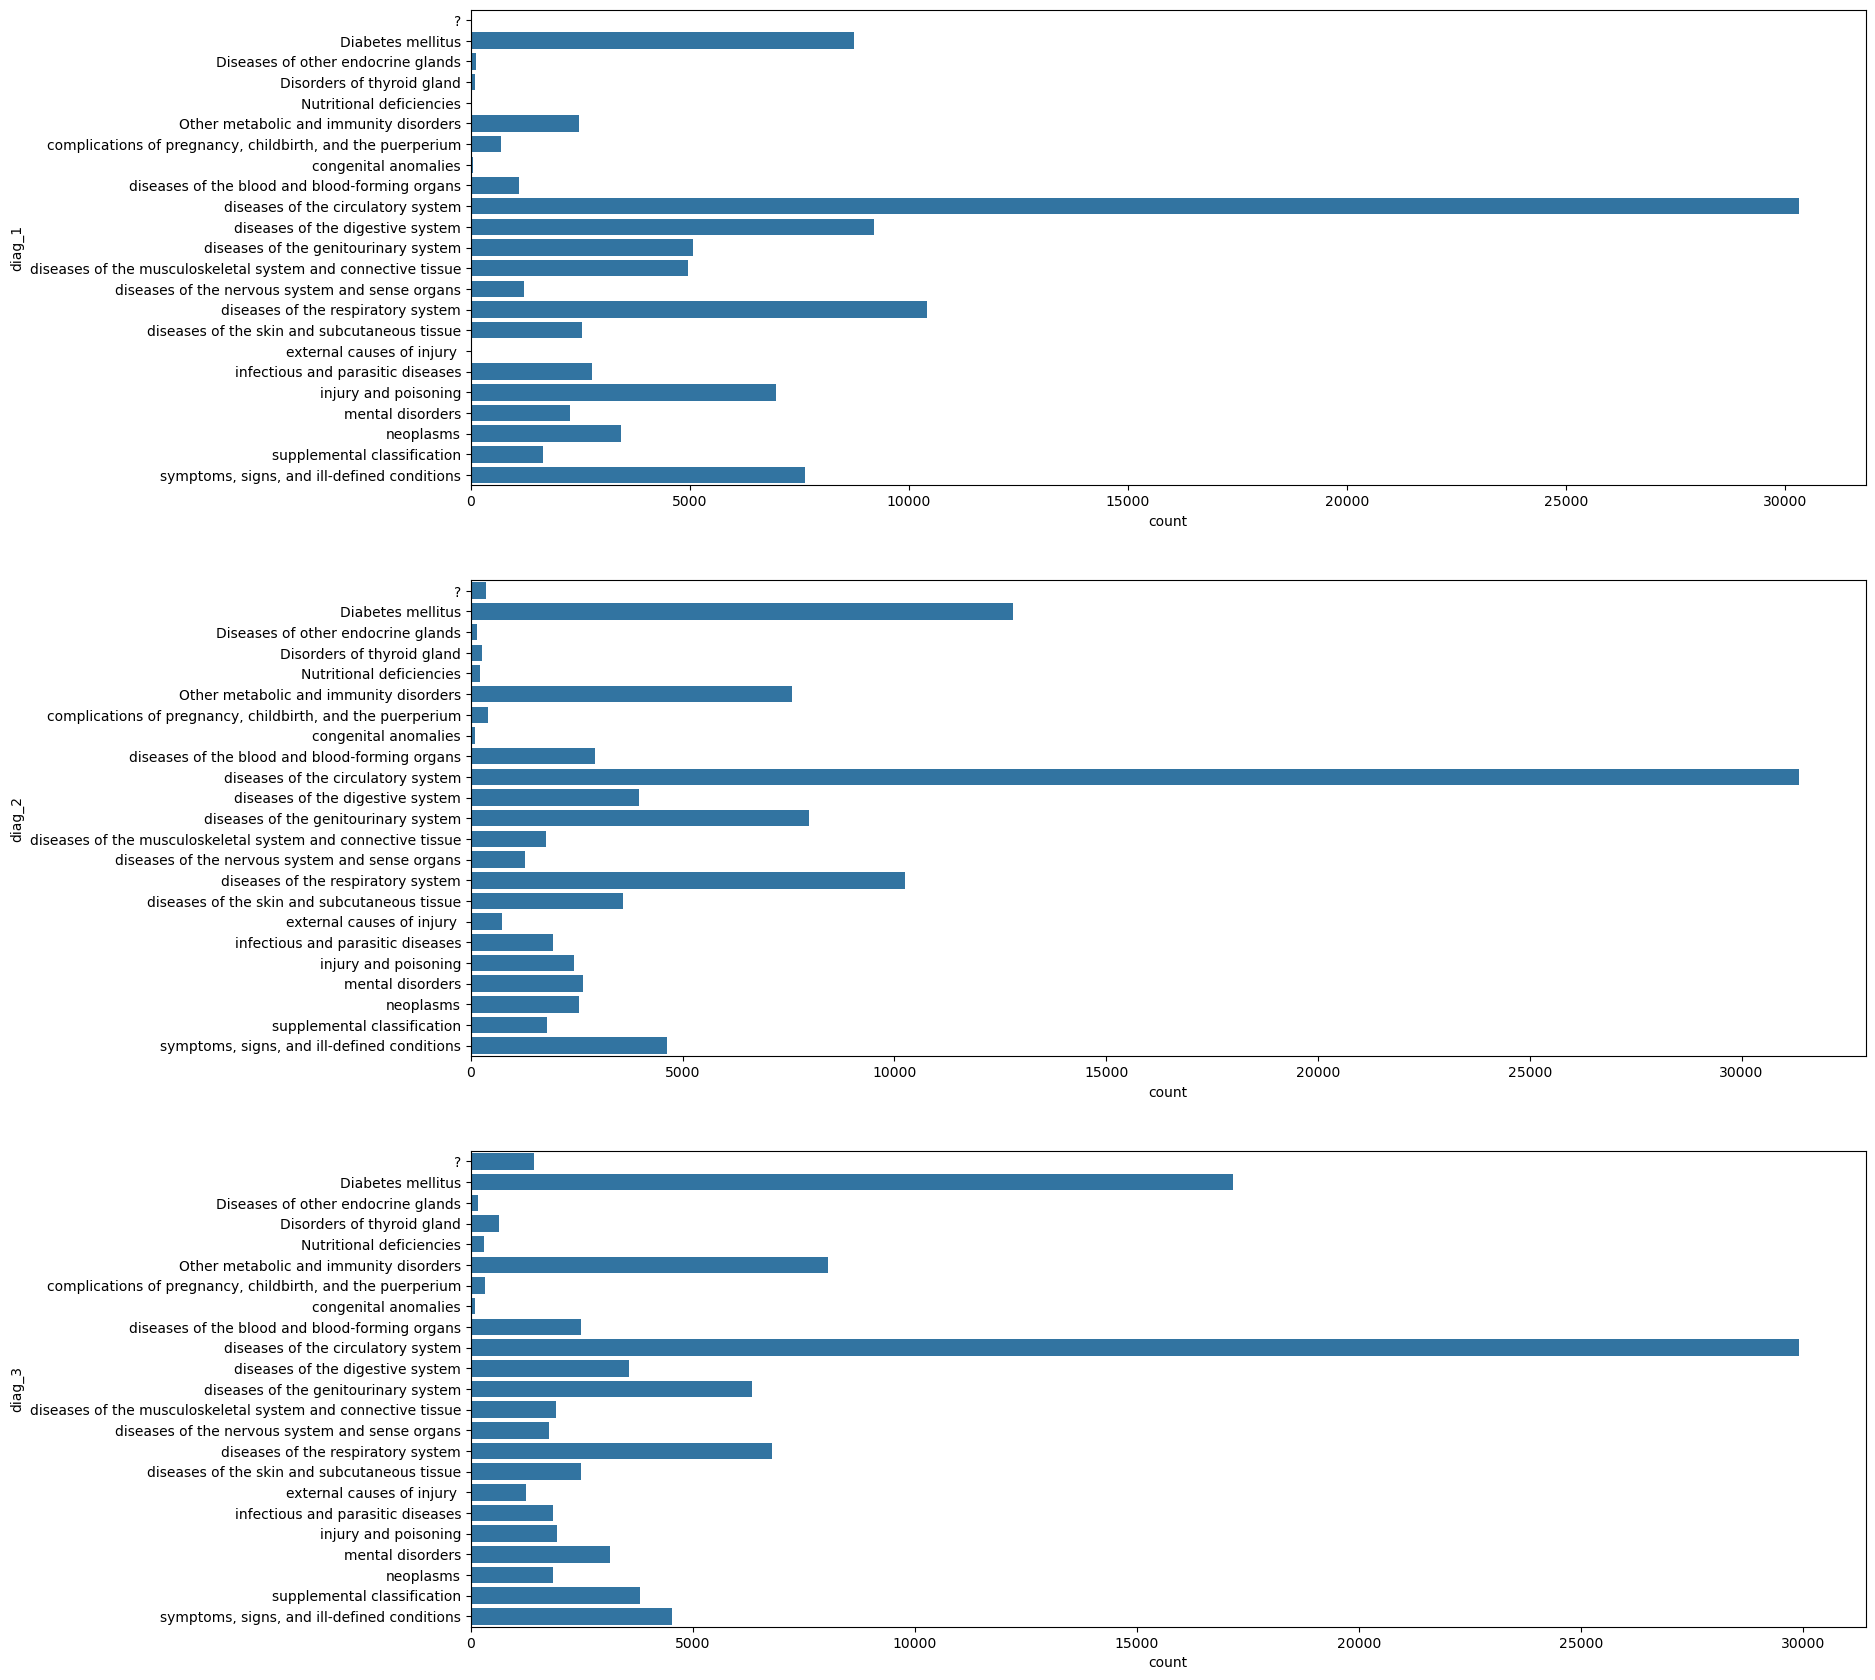

In [18]:
fig, axs = plt.subplots(nrows=3, figsize=(18, 7 * 3))
sns.countplot(df2.sort("diag_1").to_pandas(), y="diag_1", ax=axs[0]);
sns.countplot(df2.sort("diag_2").to_pandas(), y="diag_2", ax=axs[1]);
sns.countplot(df2.sort("diag_3").to_pandas(), y="diag_3", ax=axs[2]);

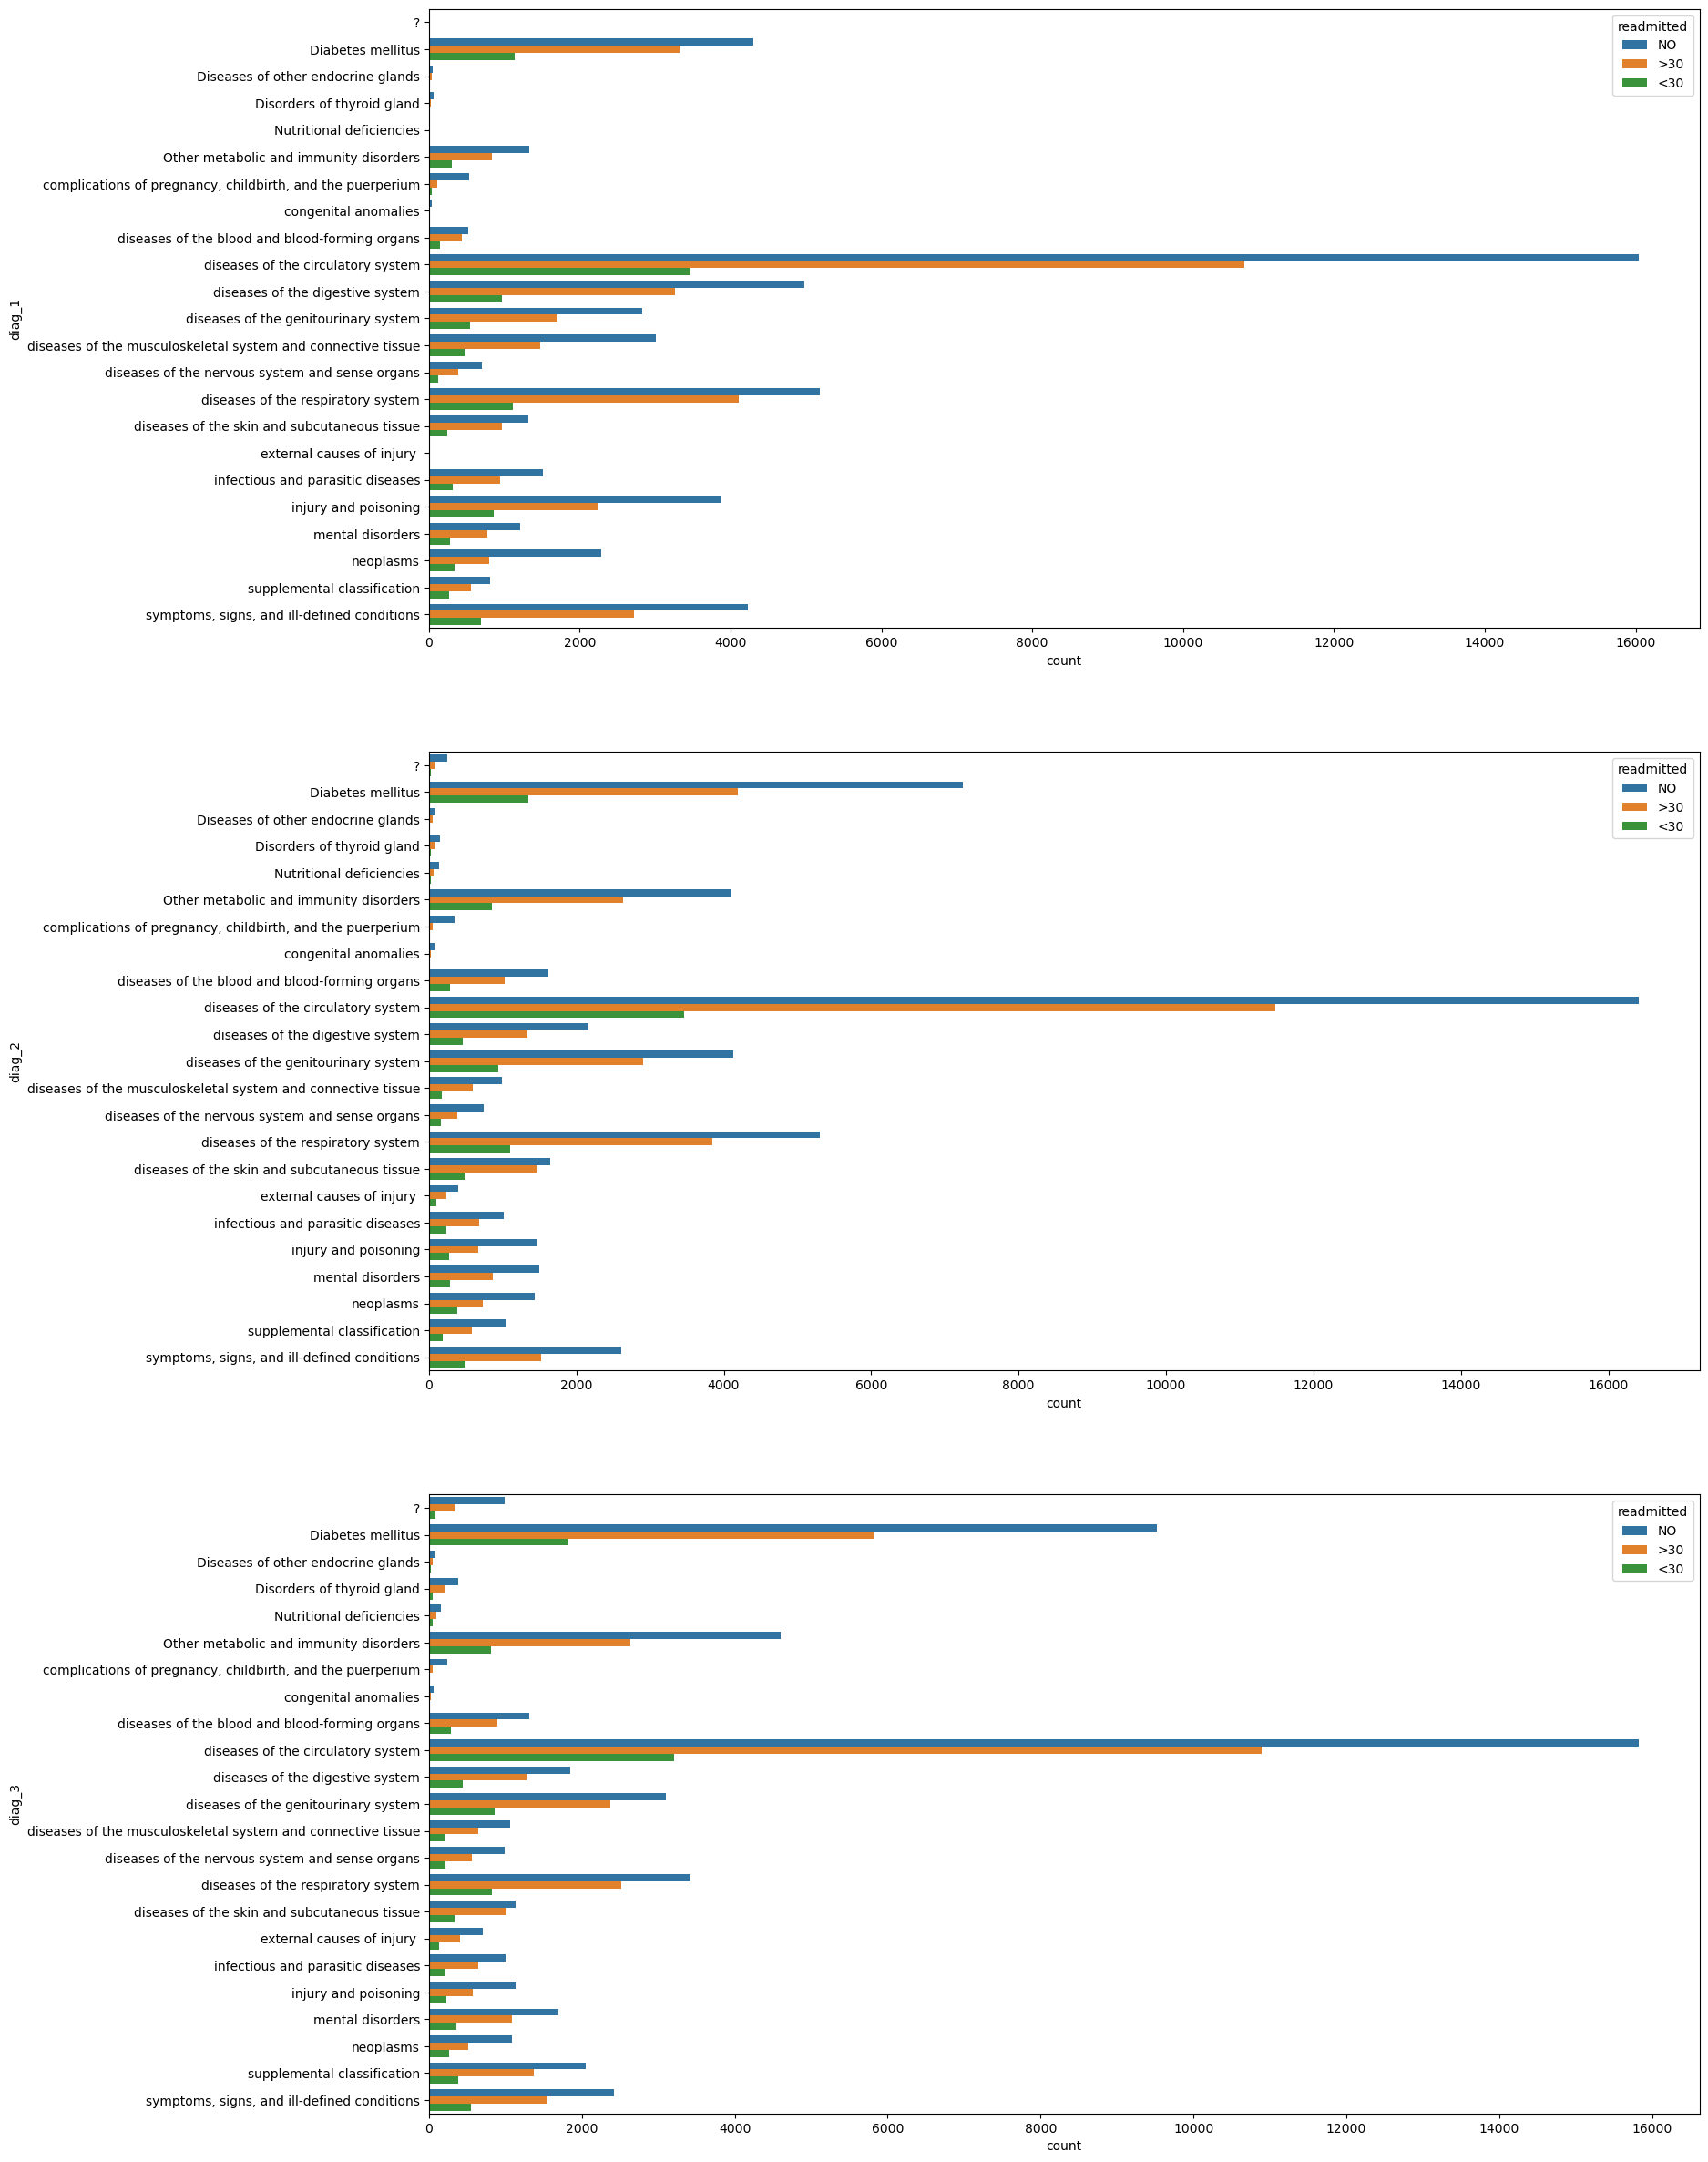

In [19]:
fig, axs = plt.subplots(nrows=3, figsize=(18, 10 * 3))
sns.countplot(df2.sort("diag_1").to_pandas(), y="diag_1", hue="readmitted", ax=axs[0]);
sns.countplot(df2.sort("diag_2").to_pandas(), y="diag_2", hue="readmitted", ax=axs[1]);
sns.countplot(df2.sort("diag_3").to_pandas(), y="diag_3", hue="readmitted", ax=axs[2]);

---

## `discharge_disposition_id`

What's:
- ICF
- SNF

Look out for:
- Discharged/transferred to a long term care hospital
- Expired...
- Hospice...

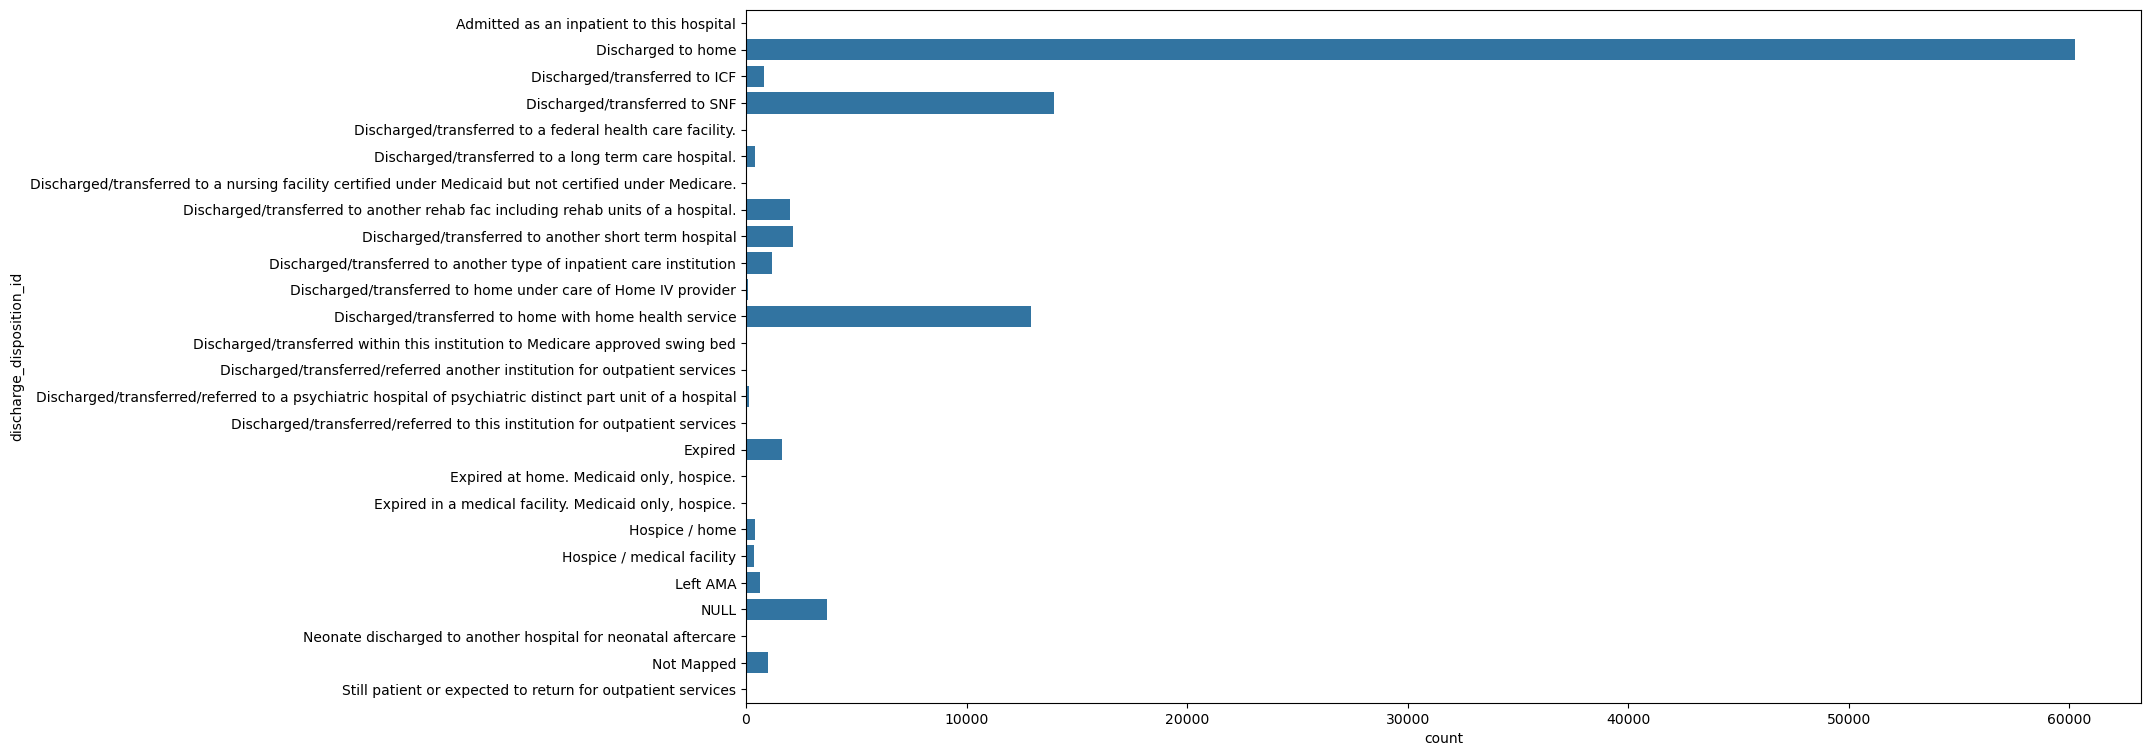

In [20]:
fig, ax = plt.subplots(figsize=(18, 9))
sns.countplot(df2.sort("discharge_disposition_id").to_pandas(), y="discharge_disposition_id", ax=ax);

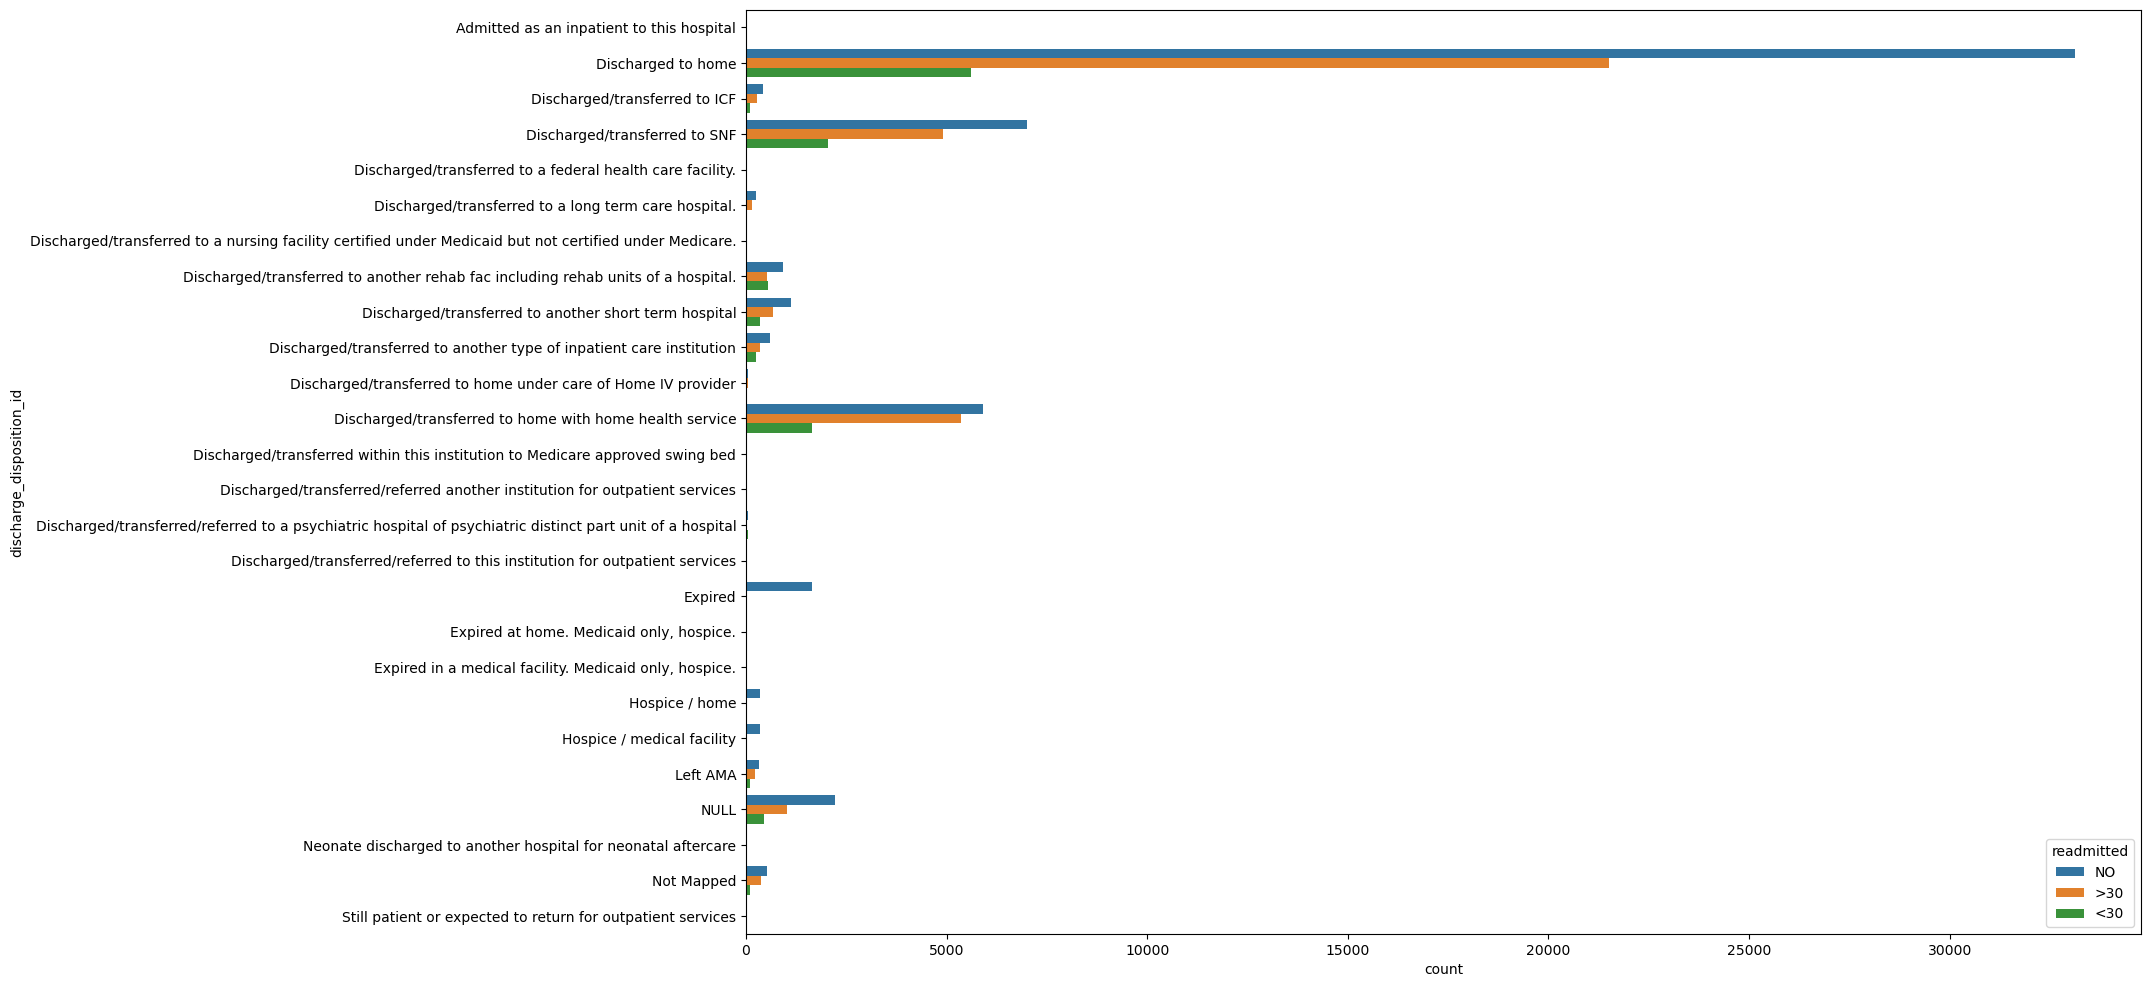

In [21]:
fig, ax = plt.subplots(figsize=(18, 12))
sns.countplot(df2.sort("discharge_disposition_id").to_pandas(), y="discharge_disposition_id", hue="readmitted", ax=ax);

### "Expired..." are the only categories with guaranteed zero readmissions

These are not true "positive" cases which might contribute noise to the learning process, and should be removed.

In [22]:
def discharge_xtab(df: pl.DataFrame) -> pl.DataFrame:
    tot = pl.sum_horizontal(pl.exclude("discharge_disposition_id"))
    df = (
        df
        .group_by("discharge_disposition_id", "readmitted").len()
        .sort("discharge_disposition_id", "readmitted")
        .pivot(index="discharge_disposition_id", on="readmitted")
        .sort(pl.col("NO") / tot, descending=True)
    )
    return df

with pl.Config(fmt_str_lengths=200, tbl_rows=-1) as cfg:
    display(discharge_xtab(df2))

discharge_disposition_id,NO,>30,<30
str,u32,u32,u32
"""Expired""",1642,null,null
"""Expired at home. Medicaid only, hospice.""",8,null,null
"""Expired in a medical facility. Medicaid only, hospice.""",2,null,null
"""Hospice / medical facility""",341,7,24
"""Hospice / home""",344,36,19
"""Discharged/transferred to a federal health care facility.""",4,1,null
"""Discharged/transferred/referred to this institution for outpatient services""",9,5,null
"""NULL""",2205,1027,459
"""Discharged/transferred to a long term care hospital.""",238,144,30


---

## What new variables might be useful for further EDA?
- `n_admissions`
- (Re-)Recoded `diag_1`, `diag_2`, `diag_3`
- `expired` (boolean)
- ...